# QM640 Data Analytics Capstone
## Predicting Life Expectancy and Premature NCD Mortality in Saudi Arabia and MENA Comparator Countries

**by** Mohamad AboRashd  
**Course:** QM640 Data Analytics Capstone  
**Term:** Summer 2026

This revised notebook implements the approved analysis plan and corrects issues identified in the first executed version. It uses reproducible data validation, descriptive analysis, least-squares dummy-variable two-way fixed effects, robust diagnostics, Saudi trajectory analysis, UHC moderation, country-grouped out-of-fold machine-learning validation, and sensitivity analysis.

## How to use this notebook

Upload the QM640 Excel dataset to the same Colab session, then select **Runtime → Run all**. The notebook first looks for the preferred filename `AboRashd_QM640_Capstone_Data.xlsx`; if it is not present, it searches `/content` for another Excel file beginning with `AboRashd_QM640`.

Each code cell is preceded by a rationale and followed by an interpretation note so the notebook documents both the analytical decision and the meaning of the output.


### 0.1 Environment and reproducibility setup

Import the required libraries and creates a reproducible folder structure. The revised notebook uses `statsmodels` dummy-variable fixed effects rather than requiring the external `linearmodels` package, making it more reliable in Google Colab and fully equivalent to including country and year fixed effects.


In [1]:
import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

# Prefer the official project filename, but allow a closely matching upload
# so that minor filename changes do not stop the Colab workflow.
preferred_file = Path("/content/AboRashd_QM640_Data.xlsx")

if preferred_file.exists():
    DATA_FILE = preferred_file
else:
    candidate_files = sorted(Path("/content").glob("AboRashd_QM640*.xlsx"))

    if len(candidate_files) == 0:
        raise FileNotFoundError(
            "No QM640 Excel dataset was found in /content. "
            "Upload AboRashd_QM640_Capstone_Data.xlsx and rerun the notebook."
        )

    if len(candidate_files) > 1:
        print(
            "Multiple matching Excel files were found. "
            f"The notebook will use: {candidate_files[0].name}"
        )

    DATA_FILE = candidate_files[0]

OUTPUT_DIR = Path("qm640_final_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(exist_ok=True, parents=True)

print("Environment ready.")
print("Dataset selected:", DATA_FILE.name)


Environment ready.
Dataset selected: AboRashd_QM640_Data.xlsx



A successful output of **“Environment ready.”** confirms that all packages loaded and the output folders were created. The additional **“Dataset selected”** message confirms which uploaded Excel file will be analysed. No statistical conclusion is drawn yet.


# 1. Data loading and validation

### 1.1 Load the analytical workbook

Load the master panel and supporting sheets from the final Excel workbook. Loading named sheets prevents accidental use of an outdated or wrong worksheet.


In [2]:
# Confirm that the required workbook exists before attempting to read it.
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE.name} was not found. Upload it to Colab and rerun the notebook."
    )

# Read the workbook structure first so the code can adapt to whichever
# supporting worksheets are actually present.
xls = pd.ExcelFile(DATA_FILE)
print("Workbook sheets:", xls.sheet_names)

# The analytical panel is the only essential worksheet.
if "Master_Panel_Data" not in xls.sheet_names:
    raise ValueError(
        "The workbook must contain a worksheet named 'Master_Panel_Data'."
    )

df = pd.read_excel(DATA_FILE, sheet_name="Master_Panel_Data")

# Supporting worksheets are optional. If they are absent, create empty
# DataFrames so that the rest of the notebook can continue safely.
if "Data_Dictionary" in xls.sheet_names:
    data_dictionary = pd.read_excel(DATA_FILE, sheet_name="Data_Dictionary")
    print("Data dictionary loaded from the workbook.")
else:
    data_dictionary = pd.DataFrame()
    print(
        "Data_Dictionary worksheet not found. "
        "The analysis will continue using the Master_Panel_Data worksheet."
    )

if "Missingness_Summary" in xls.sheet_names:
    missingness_source = pd.read_excel(
        DATA_FILE,
        sheet_name="Missingness_Summary"
    )
else:
    missingness_source = pd.DataFrame()

if "Descriptive_Statistics" in xls.sheet_names:
    descriptive_source = pd.read_excel(
        DATA_FILE,
        sheet_name="Descriptive_Statistics"
    )
else:
    descriptive_source = pd.DataFrame()

print("Dataset shape:", df.shape)
display(df.head())


Workbook sheets: ['Master_Panel_Data']
Data_Dictionary worksheet not found. The analysis will continue using the Master_Panel_Data worksheet.
Dataset shape: (288, 12)


,Country,Year,LifeExpectancy,HealthExpPC,HealthExpGDP,Physicians,UHCIndex,NCDMortality,OldAgeDependency,OOPExpenditure,HALE,HealthGap
0,ARE,2000,76.347,706.031128,2.395045,1.616,73,61.84,1.637074,22.083435,67.45,8.897
1,ARE,2001,77.621,689.292786,2.484364,1.759,74,60.10,1.733847,15.085933,67.56,10.061
2,ARE,2002,78.721,754.262207,2.717709,1.761,74,58.32,1.834854,28.041508,67.61,11.111
3,ARE,2003,79.600,784.893433,2.646344,1.838,74,55.59,1.941747,27.456930,67.75,11.850
4,ARE,2004,80.272,821.749207,2.462256,1.762,74,54.06,2.060574,30.408381,67.96,12.312



The expected analytical file contains **288 country-year observations and 12 original variables**. The preview should show one row per country and year, confirming a long-format panel suitable for country and year fixed effects.

### 1.2 Validate the panel structure

Validate and check the dimensions, variable names, panel coverage, duplicate keys, and missing identifiers. These checks protect all later models from silent structural errors.


In [3]:
expected_columns = [
    "Country", "Year", "LifeExpectancy", "HealthExpPC", "HealthExpGDP",
    "Physicians", "UHCIndex", "NCDMortality", "OldAgeDependency",
    "OOPExpenditure", "HALE", "HealthGap"
]

structural_checks = pd.DataFrame({
    "Check": [
        "Expected 288 rows", "Expected 12 columns", "Expected variables and order",
        "Exactly 12 countries", "Years span 2000–2023",
        "No duplicate Country-Year keys", "No missing Country", "No missing Year"
    ],
    "Passed": [
        len(df) == 288, df.shape[1] == 12, list(df.columns) == expected_columns,
        df["Country"].nunique() == 12,
        df["Year"].min() == 2000 and df["Year"].max() == 2023,
        df.duplicated(["Country", "Year"]).sum() == 0,
        df["Country"].isna().sum() == 0, df["Year"].isna().sum() == 0
    ]
})
display(structural_checks)
structural_checks.to_csv(TABLE_DIR / "table_1_structural_validation.csv", index=False)
assert structural_checks["Passed"].all(), "Structural validation failed."


,Check,Passed
0,Expected 288 rows,True
1,Expected 12 columns,True
2,Expected variables and order,True
3,Exactly 12 countries,True
4,Years span 2000–2023,True
5,No duplicate Country-Year keys,True
6,No missing Country,True
7,No missing Year,True



All checks return **True**. This confirms that the dataset has the planned 12-country, 2000–2023 structure and that no duplicate country-year records would distort the panel analysis.

# 2. Cleaning and feature engineering

### 2.1 Enforce data types and engineer variables

Enforce numeric types, checks plausible ranges, creates the log expenditure variable, mean-centred moderation terms, and policy-period indicators. No broad mean imputation is applied because unsupported imputation could bias country-level relationships.


In [4]:
df["Country"] = df["Country"].astype(str)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)
numeric_cols = [c for c in expected_columns if c not in ["Country", "Year"]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

range_rules = {
    "LifeExpectancy": (0, 100), "HealthExpPC": (0, np.inf),
    "HealthExpGDP": (0, 100), "Physicians": (0, 20),
    "UHCIndex": (0, 100), "NCDMortality": (0, 100),
    "OldAgeDependency": (0, 100), "OOPExpenditure": (0, 100),
    "HALE": (0, 100), "HealthGap": (-10, 50)
}
range_log=[]
for col,(low,high) in range_rules.items():
    invalid=df[col].notna() & ((df[col]<low)|(df[col]>high))
    range_log.append({"Variable":col,"Invalid_Count":int(invalid.sum()),"Allowed_Range":f"{low} to {high}"})
range_log=pd.DataFrame(range_log)

df["LogHealthExpPC"] = np.where(df["HealthExpPC"] > 0, np.log(df["HealthExpPC"]), np.nan)
df["CenteredLogHealthExpPC"] = df["LogHealthExpPC"] - df["LogHealthExpPC"].mean()
df["CenteredUHCIndex"] = df["UHCIndex"] - df["UHCIndex"].mean()
df["Expenditure_UHC_Interaction"] = df["CenteredLogHealthExpPC"] * df["CenteredUHCIndex"]
df["Pandemic"] = df["Year"].isin([2020, 2021]).astype(int)
df["Post2016"] = (df["Year"] >= 2016).astype(int)

gcc = {"SAU", "ARE", "BHR", "KWT", "OMN", "QAT"}
df["ComparisonGroup"] = np.where(
    df["Country"].eq("SAU"), "Saudi Arabia",
    np.where(df["Country"].isin(gcc - {"SAU"}), "Other GCC", "Selected non-GCC MENA")
)

display(range_log)
range_log.to_csv(TABLE_DIR / "table_2_range_validation.csv", index=False)


,Variable,Invalid_Count,Allowed_Range
0,LifeExpectancy,0,0 to 100
1,HealthExpPC,0,0 to inf
2,HealthExpGDP,0,0 to 100
3,Physicians,0,0 to 20
4,UHCIndex,0,0 to 100
5,NCDMortality,0,0 to 100
6,OldAgeDependency,0,0 to 100
7,OOPExpenditure,0,0 to 100
8,HALE,0,0 to 100
9,HealthGap,0,-10 to 50



The executed dataset contained **no values outside the predefined plausible ranges**. The log transformation is justified because expenditure per capita is strongly right-skewed, while centring makes the interaction coefficient and lower-order moderation terms easier to interpret.

### 2.2 Record the data-cleaning audit trail

Record the cleaning decisions in a formal audit trail. The table can be inserted directly into the Interim Report to show what was checked, changed, and retained.


In [5]:
cleaning_log = pd.DataFrame([
    ["Duplicate country-year records", "Country, Year", "Duplicate-key check", "None required", "No duplicates detected"],
    ["Missing values", "Several health variables", "Counts and percentages", "RQ-specific complete cases", "Avoid unsupported imputation"],
    ["Right-skewed expenditure", "HealthExpPC", "Histogram and summary statistics", "Natural-log transformation", "Reduce skew and improve interpretation"],
    ["Moderation nonessential multicollinearity", "Expenditure and UHC", "Model design", "Mean centring", "Improve interpretation of lower-order terms"],
    ["Potential pandemic disruption", "2020–2021", "Time-period review", "Pandemic sensitivity indicator", "Test robustness to common shock"]
], columns=["Issue","Variables_Affected","Detection_Method","Treatment","Rationale"])
display(cleaning_log)
cleaning_log.to_csv(TABLE_DIR / "table_3_cleaning_log.csv", index=False)


,Issue,Variables_Affected,Detection_Method,Treatment,Rationale
0,Duplicate country-year records,"Country, Year",Duplicate-key check,None required,No duplicates detected
1,Missing values,Several health variables,Counts and percentages,RQ-specific complete cases,Avoid unsupported imputation
2,Right-skewed expenditure,HealthExpPC,Histogram and summary statistics,Natural-log transformation,Reduce skew and improve interpretation
3,Moderation nonessential multicollinearity,Expenditure and UHC,Model design,Mean centring,Improve interpretation of lower-order terms
4,Potential pandemic disruption,2020–2021,Time-period review,Pandemic sensitivity indicator,Test robustness to common shock


The cleaning log demonstrates that transformations were theory-driven and transparent. The main inferential models use complete cases for the variables required by each research question, with reduced-specification sensitivity models used to examine the impact of physician-density missingness.

# 3. Missingness and descriptive statistics

### 3.1 Quantify missing data

Quantify missingness before modelling. Missingness is reported for the original variables only so derived variables do not duplicate the same underlying missing-data problem.


,Variable,Missing_Count,Missing_Percent,Available_Count
5,Physicians,98,34.03,190
11,HealthGap,24,8.33,264
7,NCDMortality,24,8.33,264
10,HALE,24,8.33,264
9,OOPExpenditure,3,1.04,285
4,HealthExpGDP,3,1.04,285
3,HealthExpPC,3,1.04,285
0,Country,0,0.00,288
2,LifeExpectancy,0,0.00,288
1,Year,0,0.00,288


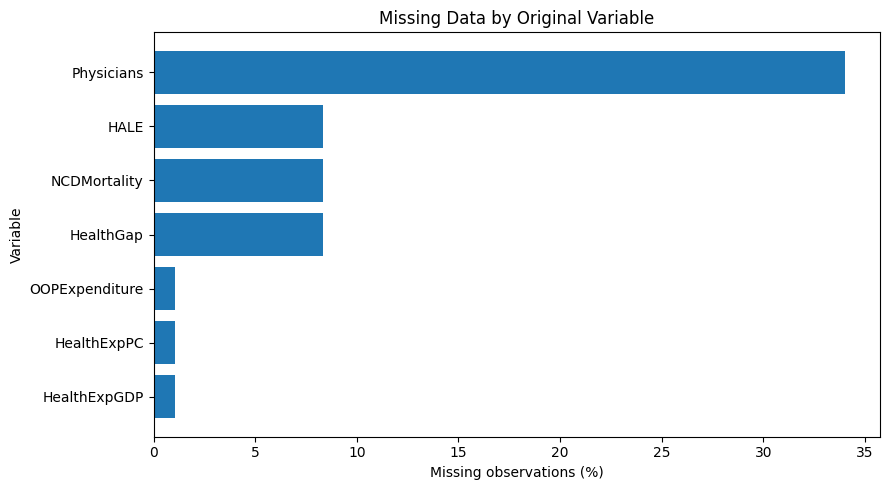

In [6]:
missingness = pd.DataFrame({
    "Variable": expected_columns,
    "Missing_Count": [df[c].isna().sum() for c in expected_columns],
    "Missing_Percent": [round(df[c].isna().mean()*100,2) for c in expected_columns],
    "Available_Count": [df[c].notna().sum() for c in expected_columns]
}).sort_values("Missing_Percent", ascending=False)
display(missingness)
missingness.to_csv(TABLE_DIR / "table_4_missingness.csv", index=False)

plot_missing=missingness[missingness["Missing_Count"]>0].sort_values("Missing_Percent")
plt.figure(figsize=(9,5))
plt.barh(plot_missing["Variable"], plot_missing["Missing_Percent"])
plt.xlabel("Missing observations (%)")
plt.ylabel("Variable")
plt.title("Missing Data by Original Variable")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_1_missingness.png", dpi=300, bbox_inches="tight")
plt.show()



Physician density has the largest missingness: **98 observations (34.03%)**. NCD mortality, HALE, and HealthGap each have **24 missing observations (8.33%)**, while expenditure measures have only **3 missing values (1.04%)**. Physician density therefore drives most of the reduction in the full-model sample.

### 3.2 Summarise the original variables

TProvide central tendency, dispersion, range, and missingness for all original numeric variables. These statistics establish scale and variation before inferential modelling.


In [7]:
descriptive = df[numeric_cols].describe().T.rename(columns={
    "count":"N","mean":"Mean","std":"SD","min":"Minimum",
    "25%":"Q1","50%":"Median","75%":"Q3","max":"Maximum"
})
descriptive["Missing"] = df[numeric_cols].isna().sum()
descriptive["Missing_Percent"] = (df[numeric_cols].isna().mean()*100).round(2)
display(descriptive.round(3))
descriptive.round(4).to_csv(TABLE_DIR / "table_5_descriptive_statistics.csv")


,N,Mean,SD,Minimum,Q1,Median,Q3,Maximum,Missing,Missing_Percent
LifeExpectancy,288.0,75.381,4.362,64.029,72.894,75.685,78.445,83.188,0,0.00
HealthExpPC,285.0,676.154,592.910,26.983,189.858,462.178,1080.089,2422.645,3,1.04
HealthExpGDP,285.0,4.690,1.925,1.600,3.185,4.379,5.575,10.830,3,1.04
Physicians,190.0,1.744,0.767,0.483,0.987,1.892,2.273,4.048,98,34.03
UHCIndex,288.0,73.403,6.870,55.000,68.000,74.000,79.000,84.000,0,0.00
NCDMortality,264.0,56.068,9.916,34.180,48.598,57.495,61.863,75.150,24,8.33
OldAgeDependency,288.0,5.340,3.139,1.012,2.997,4.804,7.357,15.481,0,0.00
OOPExpenditure,285.0,30.733,17.325,5.208,15.898,28.616,42.675,76.191,3,1.04
HALE,264.0,64.625,2.827,58.120,62.280,64.725,66.610,70.800,24,8.33
HealthGap,264.0,10.532,2.625,5.170,8.578,9.997,12.845,15.264,24,8.33



Across the full panel, mean life expectancy is approximately **75.38 years**, mean premature NCD mortality is **56.07**, and average health expenditure per capita is about US$676.15.

The expenditure mean exceeds the median US$462.18, confirming right-skewness and supporting the log transformation.

### 3.3 Determine research-question sample sizes

Calculate complete-case sample sizes separately for each research question. Reporting model-specific N is essential because different outcomes and predictors have different missingness patterns.


In [8]:
full_features=["LogHealthExpPC","HealthExpGDP","Physicians","UHCIndex","OldAgeDependency","OOPExpenditure"]
rq_samples=pd.DataFrame({
    "Analysis":["RQ1 full life-expectancy model","RQ2 trajectory model","RQ3 full NCD-mortality model","RQ4a life-expectancy moderation","RQ4b NCD-mortality moderation","HALE descriptive analysis"],
    "Complete_Cases":[
        df[["LifeExpectancy"]+full_features].dropna().shape[0],
        df[["Country","Year","LifeExpectancy"]].dropna().shape[0],
        df[["NCDMortality"]+full_features].dropna().shape[0],
        df[["LifeExpectancy"]+full_features].dropna().shape[0],
        df[["NCDMortality"]+full_features].dropna().shape[0],
        df[["HALE"]].dropna().shape[0]
    ]
})
display(rq_samples)
rq_samples.to_csv(TABLE_DIR / "table_6_rq_sample_sizes.csv", index=False)


,Analysis,Complete_Cases
0,RQ1 full life-expectancy model,189
1,RQ2 trajectory model,288
2,RQ3 full NCD-mortality model,181
3,RQ4a life-expectancy moderation,189
4,RQ4b NCD-mortality moderation,181
5,HALE descriptive analysis,264



The full life-expectancy model uses **189 observations**, and the full NCD-mortality model uses **181**. The trajectory model retains all **288 observations**. These values match the approved synopsis and confirm that missing physician-density data is the main constraint on multivariable analyses.

# 4. Exploratory data analysis

### 4.1 Examine bivariate correlations

The correlation matrix describes bivariate associations and helps identify possible collinearity. It is exploratory only and does not control for country or year effects.


,LifeExpectancy,HealthExpPC,HealthExpGDP,Physicians,UHCIndex,NCDMortality,OldAgeDependency,OOPExpenditure,HALE,HealthGap
LifeExpectancy,1.000,0.809,-0.137,0.580,0.641,0.105,-0.412,-0.719,0.816,0.782
HealthExpPC,0.809,1.000,-0.289,0.598,0.723,0.429,-0.626,-0.708,0.615,0.683
HealthExpGDP,-0.137,-0.289,1.000,0.147,-0.287,-0.557,0.609,0.366,0.117,-0.351
Physicians,0.580,0.598,0.147,1.000,0.586,0.292,-0.287,-0.596,0.574,0.270
UHCIndex,0.641,0.723,-0.287,0.586,1.000,0.508,-0.637,-0.669,0.452,0.562
NCDMortality,0.105,0.429,-0.557,0.292,0.508,1.000,-0.727,-0.379,0.090,0.077
OldAgeDependency,-0.412,-0.626,0.609,-0.287,-0.637,-0.727,1.000,0.601,-0.196,-0.535
OOPExpenditure,-0.719,-0.708,0.366,-0.596,-0.669,-0.379,0.601,1.000,-0.504,-0.623
HALE,0.816,0.615,0.117,0.574,0.452,0.090,-0.196,-0.504,1.000,0.278
HealthGap,0.782,0.683,-0.351,0.270,0.562,0.077,-0.535,-0.623,0.278,1.000


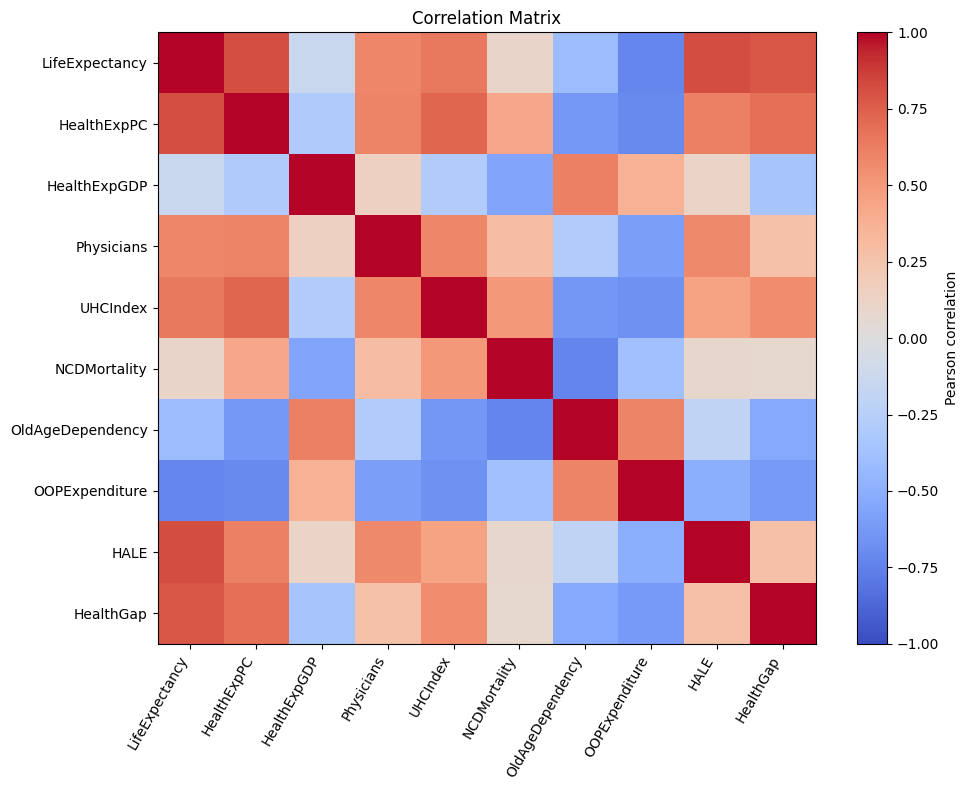

In [9]:
corr_vars=["LifeExpectancy","HealthExpPC","HealthExpGDP","Physicians","UHCIndex","NCDMortality","OldAgeDependency","OOPExpenditure","HALE","HealthGap"]
corr=df[corr_vars].corr()
display(corr.round(3))
corr.round(4).to_csv(TABLE_DIR / "table_7_correlations.csv")
plt.figure(figsize=(10,8))
img=plt.imshow(corr,aspect="auto",vmin=-1,vmax=1,cmap="coolwarm")
plt.colorbar(img,label="Pearson correlation")
plt.xticks(range(len(corr_vars)),corr_vars,rotation=60,ha="right")
plt.yticks(range(len(corr_vars)),corr_vars)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_2_correlations.png",dpi=300,bbox_inches="tight")
plt.show()


Life expectancy is strongly positively correlated with health expenditure per capita (**r ≈ 0.81**) and HALE (**r ≈ 0.82**), and negatively correlated with out-of-pocket expenditure (**r ≈ −0.72**). These are pooled correlations and must not be interpreted as causal or as equivalent to within-country fixed-effects estimates.

### 4.2 Assess the expenditure transformation


These histograms compare expenditure before and after log transformation. The transformation is retained only if it visibly reduces right-skewness.


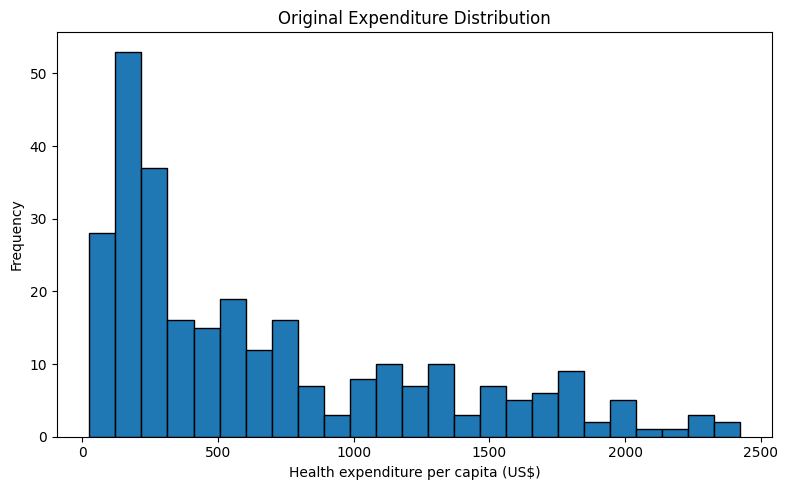

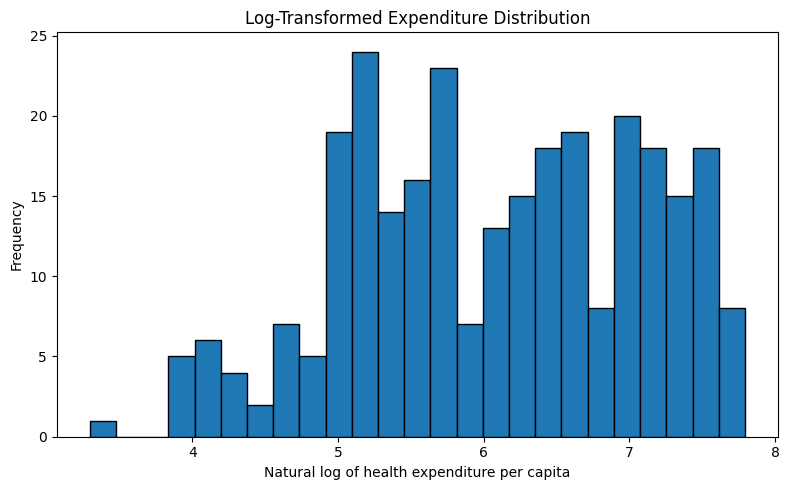

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["HealthExpPC"].dropna(),bins=25,edgecolor="black")
plt.xlabel("Health expenditure per capita (US$)")
plt.ylabel("Frequency")
plt.title("Original Expenditure Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_expenditure_original.png",dpi=300,bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["LogHealthExpPC"].dropna(),bins=25,edgecolor="black")
plt.xlabel("Natural log of health expenditure per capita")
plt.ylabel("Frequency")
plt.title("Log-Transformed Expenditure Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_4_expenditure_log.png",dpi=300,bbox_inches="tight")
plt.show()


The original distribution has a long upper tail, whereas the log-transformed distribution is substantially more balanced. The log specification is therefore preferable for regression and also permits a percentage-change interpretation of expenditure effects.

### 4.3 Plot country-level life-expectancy trends

This figure displays country-specific life-expectancy trajectories. Saudi Arabia is visually emphasised to support RQ2 while retaining the full regional context.


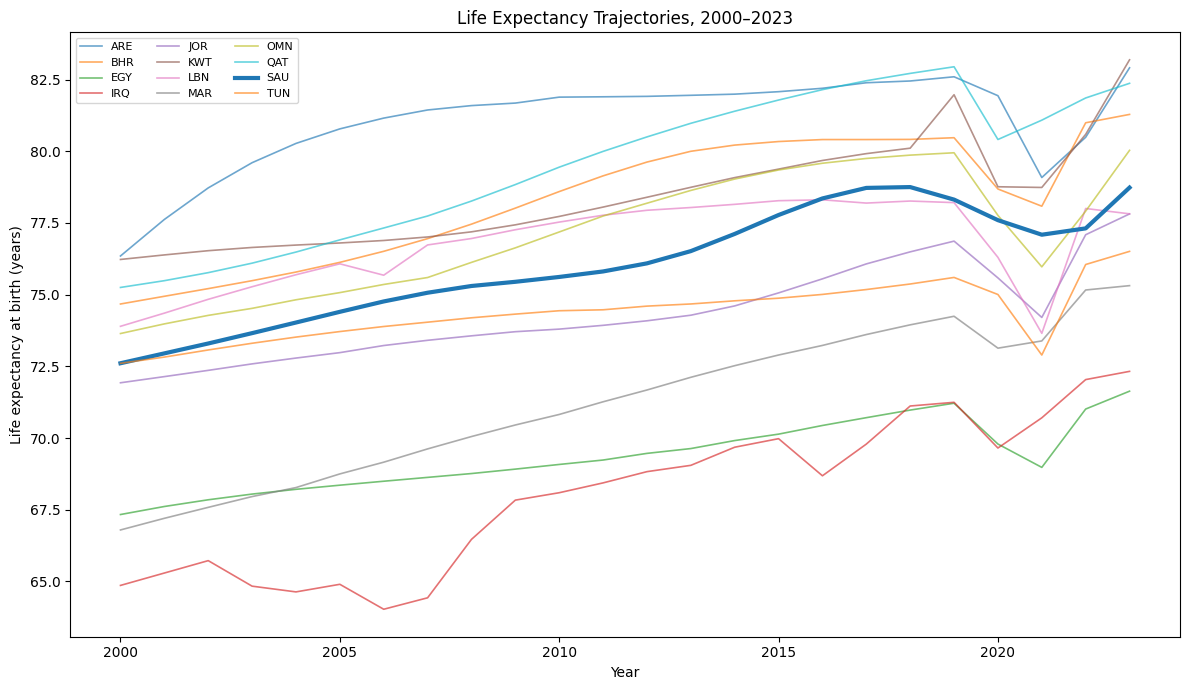

In [11]:
plt.figure(figsize=(12,7))
for country,g in df.sort_values("Year").groupby("Country"):
    plt.plot(g["Year"],g["LifeExpectancy"],label=country,linewidth=3 if country=="SAU" else 1.2,alpha=1 if country=="SAU" else .65)
plt.xlabel("Year")
plt.ylabel("Life expectancy at birth (years)")
plt.title("Life Expectancy Trajectories, 2000–2023")
plt.legend(ncol=3,fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_5_country_trends.png",dpi=300,bbox_inches="tight")
plt.show()



All countries show long-run improvement, but the rate and starting level differ. Saudi Arabia follows a clear upward path; formal slope comparisons are conducted later using heteroskedasticity-robust standard errors rather than the invalid near-zero clustered errors produced in the first notebook.

### 4.4 Compare Saudi Arabia with regional groups


This grouped trend compares Saudi Arabia with the average of the other GCC countries and the selected non-GCC MENA comparators. It provides an interpretable policy-level summary without replacing country-level analysis.


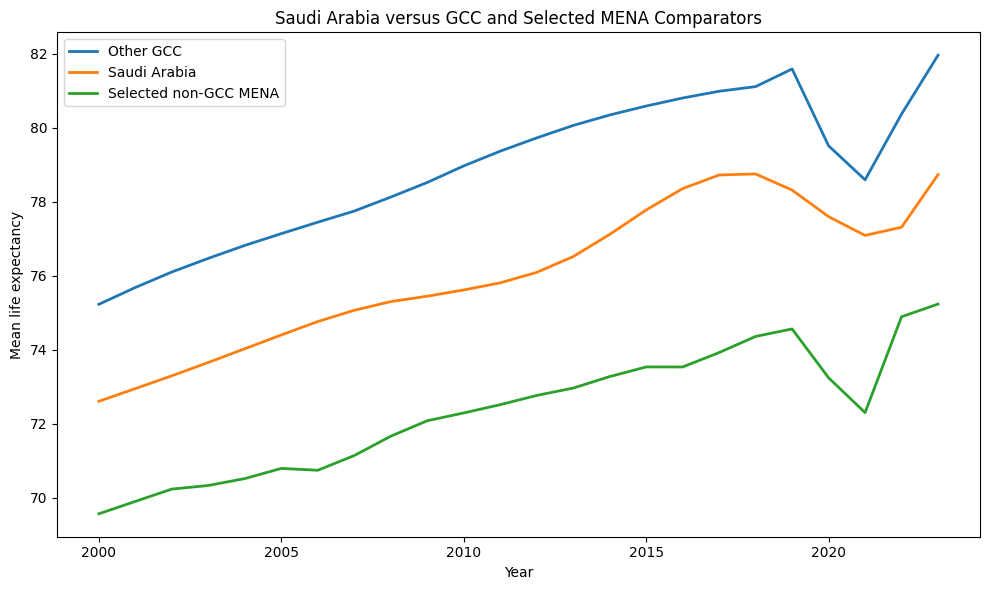

In [12]:
group_trends=df.groupby(["Year","ComparisonGroup"],as_index=False)["LifeExpectancy"].mean()
plt.figure(figsize=(10,6))
for label,g in group_trends.groupby("ComparisonGroup"):
    plt.plot(g["Year"],g["LifeExpectancy"],label=label,linewidth=2)
plt.xlabel("Year")
plt.ylabel("Mean life expectancy")
plt.title("Saudi Arabia versus GCC and Selected MENA Comparators")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_6_saudi_comparators.png",dpi=300,bbox_inches="tight")
plt.show()
group_trends.to_csv(TABLE_DIR / "table_8_saudi_comparator_trends.csv",index=False)



The comparison identifies whether Saudi Arabia is converging with or diverging from regional benchmarks over time. Because group means conceal within-group heterogeneity, the figure is descriptive and is complemented by the country-specific trajectory model.

# 5. Helper functions

### 5.1 Define reusable analytical functions

These reusable functions standardise metric calculation, VIF assessment, fixed-effects formula construction, and model-table extraction. Centralising this logic reduces coding errors and makes the notebook easier to audit.


In [13]:
def metrics(y_true,y_pred):
    return {"RMSE":float(np.sqrt(mean_squared_error(y_true,y_pred))),"MAE":float(mean_absolute_error(y_true,y_pred)),"R2":float(r2_score(y_true,y_pred))}

def vif_table(data,variables):
    x=sm.add_constant(data[variables].dropna())
    return pd.DataFrame({"Variable":x.columns,"VIF":[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]})

def fe_formula(outcome,features,extra_terms=None):
    rhs=" + ".join(features + (extra_terms or []) + ["C(Country)","C(Year)"])
    return f"{outcome} ~ {rhs}"

def coefficient_table(model,terms):
    ci=model.conf_int()
    rows=[]
    for term in terms:
        rows.append({"Variable":term,"Coefficient":model.params.get(term,np.nan),"Std_Error":model.bse.get(term,np.nan),"Statistic":model.tvalues.get(term,np.nan),"P_Value":model.pvalues.get(term,np.nan),"CI_Lower":ci.loc[term,0] if term in ci.index else np.nan,"CI_Upper":ci.loc[term,1] if term in ci.index else np.nan})
    return pd.DataFrame(rows)

print("Helper functions defined.")


Helper functions defined.



The confirmation message indicates that the shared analytical functions are available. No substantive result is produced in this cell.

# 6. RQ1 — Predictors of life expectancy

### 6.1 Estimate the pooled RQ1 baseline

The pooled OLS model is retained as a baseline only. HC3 standard errors address heteroskedasticity, while VIF values assess multicollinearity among the substantive predictors.


In [14]:
rq1_features=full_features.copy()
rq1=df[["Country","Year","LifeExpectancy"]+rq1_features].dropna().copy()
rq1_ols=smf.ols("LifeExpectancy ~ "+" + ".join(rq1_features),data=rq1).fit(cov_type="HC3")
print(rq1_ols.summary())
rq1_vif=vif_table(rq1,rq1_features)
display(rq1_vif)
with open(MODEL_DIR / "rq1_pooled_ols.txt","w") as f:f.write(rq1_ols.summary().as_text())
rq1_vif.to_csv(TABLE_DIR / "table_9_rq1_vif.csv",index=False)


                            OLS Regression Results                            
Dep. Variable:         LifeExpectancy   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     128.8
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           8.90e-63
Time:                        12:52:36   Log-Likelihood:                -354.22
No. Observations:                 189   AIC:                             722.4
Df Residuals:                     182   BIC:                             745.1
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           53.7038      3.071  

,Variable,VIF
0,const,429.571062
1,LogHealthExpPC,3.258349
2,HealthExpGDP,2.311441
3,Physicians,2.541918
4,UHCIndex,2.950246
5,OldAgeDependency,2.951234
6,OOPExpenditure,2.901245



The pooled model explains a large share of cross-sectional variation (**R² ≈ 0.84**), but its residual autocorrelation and omission of country/year effects make it unsuitable as the primary causal-style specification. Predictor VIFs are approximately **2.3–3.3**, below common concern thresholds, so severe multicollinearity is not evident.

### 6.2 Estimate the two-way fixed-effects RQ1 model

The primary RQ1 model includes country and year dummy variables, which are algebraically equivalent to two-way fixed effects. Standard errors are clustered by country to allow within-country serial correlation and heteroskedasticity. Because there are only 12 clusters, results are interpreted cautiously.


In [15]:
rq1_fe=smf.ols(fe_formula("LifeExpectancy",rq1_features),data=rq1).fit(cov_type="cluster",cov_kwds={"groups":rq1["Country"],"use_correction":True})
rq1_fe_table=coefficient_table(rq1_fe,rq1_features)
display(rq1_fe_table)
print("Adjusted R-squared:",round(rq1_fe.rsquared_adj,4),"N:",int(rq1_fe.nobs))
with open(MODEL_DIR / "rq1_two_way_fe.txt","w") as f:f.write(rq1_fe.summary().as_text())
rq1_fe_table.to_csv(TABLE_DIR / "table_10_rq1_fe.csv",index=False)


,Variable,Coefficient,Std_Error,Statistic,P_Value,CI_Lower,CI_Upper
0,LogHealthExpPC,1.060385,0.649045,1.633763,0.102309,-0.211719,2.332489
1,HealthExpGDP,0.177201,0.146042,1.213352,0.224995,-0.109037,0.463439
2,Physicians,-0.352139,0.267203,-1.317872,0.187547,-0.875848,0.171569
3,UHCIndex,-0.134892,0.044492,-3.031860,0.002431,-0.222094,-0.047690
4,OldAgeDependency,-0.078046,0.167986,-0.464598,0.642220,-0.407292,0.251200
5,OOPExpenditure,0.040122,0.013980,2.869987,0.004105,0.012722,0.067522


Adjusted R-squared: 0.9686 N: 189




After controlling for stable country characteristics and common year shocks, the estimates differ markedly from pooled OLS. This confirms that pooled cross-country associations were partly driven by persistent country differences. Coefficients should be interpreted as **within-country associations**, not causal effects.

The reported adjusted R² reflects the combined contribution of the substantive predictors, country fixed effects, and year fixed effects; it should not be attributed solely to the six health-system variables. Statistical significance should also be interpreted cautiously because the cluster-robust covariance estimates are based on only **12 country clusters**.


### 6.3 Diagnose the pooled RQ1 residuals


Residual plots, Breusch–Pagan testing, and Durbin–Watson statistics diagnose the pooled baseline. Cluster-robust fixed effects are used for inference because panel residuals are expected to be serially correlated.


,Diagnostic,Value
0,BP LM,8.531876
1,BP p-value,0.201667
2,BP F,1.434050
3,BP F p-value,0.203789
4,Durbin-Watson,0.514250


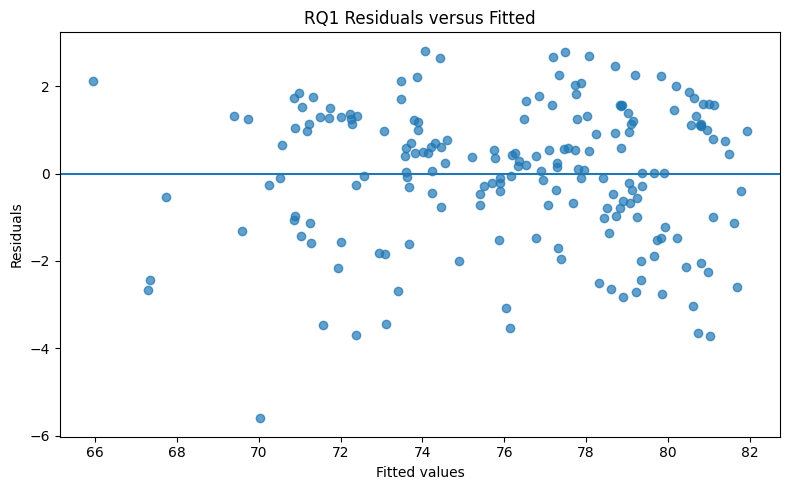

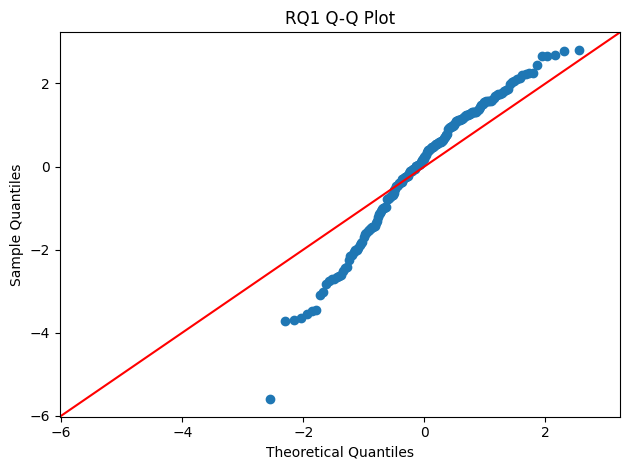

In [16]:
rq1_resid=rq1_ols.resid
bp=het_breuschpagan(rq1_resid,rq1_ols.model.exog)
rq1_diag=pd.DataFrame({"Diagnostic":["BP LM","BP p-value","BP F","BP F p-value","Durbin-Watson"],"Value":[bp[0],bp[1],bp[2],bp[3],durbin_watson(rq1_resid)]})
display(rq1_diag)
rq1_diag.to_csv(TABLE_DIR / "table_11_rq1_diagnostics.csv",index=False)
plt.figure(figsize=(8,5));plt.scatter(rq1_ols.fittedvalues,rq1_resid,alpha=.7);plt.axhline(0);plt.xlabel("Fitted values");plt.ylabel("Residuals");plt.title("RQ1 Residuals versus Fitted");plt.tight_layout();plt.savefig(FIG_DIR / "figure_7_rq1_residuals.png",dpi=300,bbox_inches="tight");plt.show()
sm.qqplot(rq1_resid,line="45");plt.title("RQ1 Q-Q Plot");plt.tight_layout();plt.savefig(FIG_DIR / "figure_8_rq1_qq.png",dpi=300,bbox_inches="tight");plt.show()



The pooled RQ1 model shows a low Durbin–Watson statistic (about **0.51**), indicating strong positive residual autocorrelation. The Breusch–Pagan test is not significant in this baseline, but serial dependence alone supports using country-clustered inference in the fixed-effects model.

# 7. RQ2 — Saudi Arabia trajectory

### 7.1 Estimate country-specific life-expectancy trajectories


The first notebook clustered standard errors by country while estimating a separate slope for every country. That saturated structure produced implausibly tiny standard errors and p-values of zero. The revised model uses HC3 heteroskedasticity-robust standard errors for country-specific slope interactions and treats the analysis as descriptive trend comparison.


In [17]:
rq2=df[["Country","Year","LifeExpectancy","Pandemic","Post2016"]].dropna().copy()
rq2["YearCentered"]=rq2["Year"]-2000
countries=sorted(rq2["Country"].unique())
rq2_model=smf.ols("LifeExpectancy ~ YearCentered * C(Country, Treatment(reference='SAU'))",data=rq2).fit(cov_type="HC3")
base=rq2_model.params["YearCentered"]
rows=[]
for country in countries:
    if country=="SAU":
        rows.append({"Country":country,"Annual_Slope":base,"Difference_vs_SAU":0.0,"P_Value_Difference":np.nan})
    else:
        term=f"YearCentered:C(Country, Treatment(reference='SAU'))[T.{country}]"
        rows.append({"Country":country,"Annual_Slope":base+rq2_model.params.get(term,0),"Difference_vs_SAU":rq2_model.params.get(term,np.nan),"P_Value_Difference":rq2_model.pvalues.get(term,np.nan)})
trajectory_table=pd.DataFrame(rows).sort_values("Country")
display(trajectory_table)
print("Model R-squared:",round(rq2_model.rsquared,4))
trajectory_table.to_csv(TABLE_DIR / "table_12_rq2_slopes.csv",index=False)
with open(MODEL_DIR / "rq2_trajectory_hc3.txt","w") as f:f.write(rq2_model.summary().as_text())


,Country,Annual_Slope,Difference_vs_SAU,P_Value_Difference
0,ARE,0.147741,-0.110554,0.079950
1,BHR,0.271245,0.012950,0.759607
2,EGY,0.155500,-0.102795,0.001768
3,IRQ,0.351531,0.093236,0.013912
4,JOR,0.217108,-0.041187,0.256619
5,KWT,0.231361,-0.026935,0.546542
6,LBN,0.123949,-0.134347,0.015698
7,MAR,0.362823,0.104527,0.000544
8,OMN,0.251970,-0.006326,0.901356
9,QAT,0.340390,0.082094,0.047943


Model R-squared: 0.9598



Saudi Arabia’s estimated linear increase is approximately **0.258 years of life expectancy per calendar year** over 2000–2023. The revised HC3 p-values are finite and interpretable, unlike the degenerate cluster results in the earlier notebook. The model remains a simplified linear summary; visual inspection and pandemic sensitivity are therefore also reported.

### 7.2 Test pandemic and post-2016 sensitivity


This sensitivity model adds common pandemic and post-2016 indicators. It tests whether the country-specific linear slopes are robust to major period shifts relevant to the study context.


Pandemic coefficient: -2.1603 p= 0.0
Post-2016 coefficient: -0.3417 p= 0.0137


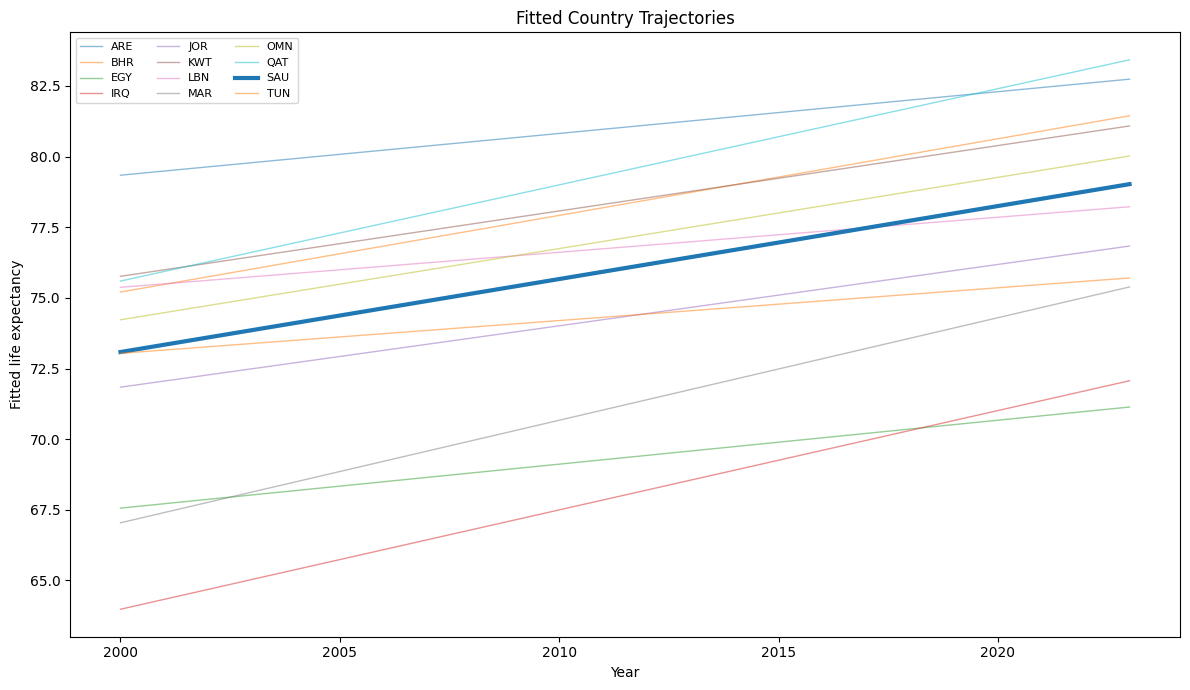

In [18]:
rq2_sensitivity=smf.ols("LifeExpectancy ~ YearCentered * C(Country, Treatment(reference='SAU')) + Pandemic + Post2016",data=rq2).fit(cov_type="HC3")
rq2["FittedTrajectory"]=rq2_model.predict(rq2)
print("Pandemic coefficient:",round(rq2_sensitivity.params.get("Pandemic",np.nan),4),"p=",round(rq2_sensitivity.pvalues.get("Pandemic",np.nan),4))
print("Post-2016 coefficient:",round(rq2_sensitivity.params.get("Post2016",np.nan),4),"p=",round(rq2_sensitivity.pvalues.get("Post2016",np.nan),4))
plt.figure(figsize=(12,7))
for country,g in rq2.sort_values("Year").groupby("Country"):
    plt.plot(g["Year"],g["FittedTrajectory"],label=country,linewidth=3 if country=="SAU" else 1,alpha=1 if country=="SAU" else .5)
plt.xlabel("Year");plt.ylabel("Fitted life expectancy");plt.title("Fitted Country Trajectories");plt.legend(ncol=3,fontsize=8);plt.tight_layout();plt.savefig(FIG_DIR / "figure_9_rq2_fitted.png",dpi=300,bbox_inches="tight");plt.show()
with open(MODEL_DIR / "rq2_sensitivity.txt","w") as f:f.write(rq2_sensitivity.summary().as_text())



The sensitivity coefficients indicate whether a common temporary pandemic disruption or a post-2016 level shift remains after accounting for country-specific trends. These indicators improve robustness but should not be interpreted as causal effects of the pandemic or Vision 2030 without a stronger quasi-experimental design.

# 8. RQ3 — Predictors of premature NCD mortality

### 8.1 Estimate the pooled RQ3 baseline


As in RQ1, pooled OLS is presented only as a baseline. HC3 errors and VIF diagnostics identify heteroskedasticity and collinearity before the preferred two-way fixed-effects specification.


In [19]:
rq3_features=full_features.copy()
rq3=df[["Country","Year","NCDMortality"]+rq3_features].dropna().copy()
rq3_ols=smf.ols("NCDMortality ~ "+" + ".join(rq3_features),data=rq3).fit(cov_type="HC3")
print(rq3_ols.summary())
rq3_vif=vif_table(rq3,rq3_features)
display(rq3_vif)
with open(MODEL_DIR / "rq3_pooled_ols.txt","w") as f:f.write(rq3_ols.summary().as_text())
rq3_vif.to_csv(TABLE_DIR / "table_13_rq3_vif.csv",index=False)


                            OLS Regression Results                            
Dep. Variable:           NCDMortality   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     87.51
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           6.33e-50
Time:                        12:52:39   Log-Likelihood:                -585.88
No. Observations:                 181   AIC:                             1186.
Df Residuals:                     174   BIC:                             1208.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           59.9291      8.522  

,Variable,VIF
0,const,422.854934
1,LogHealthExpPC,3.091652
2,HealthExpGDP,2.291174
3,Physicians,2.415028
4,UHCIndex,2.800595
5,OldAgeDependency,2.915987
6,OOPExpenditure,2.841921



The pooled RQ3 model has **R² ≈ 0.62**, but a Durbin–Watson statistic near **0.27** and strong heteroskedasticity indicate that ordinary pooled inference is inappropriate. Predictor VIFs remain below approximately 3.1, so severe multicollinearity is not the main concern.

### 8.2 Estimate the two-way fixed-effects RQ3 model

This is the preferred two-way fixed-effects RQ3 model. Country and year indicators absorb stable country differences and common annual shocks, while country-clustered standard errors address within-country dependence.


In [20]:
rq3_fe=smf.ols(fe_formula("NCDMortality",rq3_features),data=rq3).fit(cov_type="cluster",cov_kwds={"groups":rq3["Country"],"use_correction":True})
rq3_fe_table=coefficient_table(rq3_fe,rq3_features)
display(rq3_fe_table)
print("Adjusted R-squared:",round(rq3_fe.rsquared_adj,4),"N:",int(rq3_fe.nobs))
with open(MODEL_DIR / "rq3_two_way_fe.txt","w") as f:f.write(rq3_fe.summary().as_text())
rq3_fe_table.to_csv(TABLE_DIR / "table_14_rq3_fe.csv",index=False)


,Variable,Coefficient,Std_Error,Statistic,P_Value,CI_Lower,CI_Upper
0,LogHealthExpPC,-0.670314,1.962853,-0.341500,0.732727,-4.517435,3.176808
1,HealthExpGDP,-0.130505,1.044269,-0.124973,0.900545,-2.177234,1.916224
2,Physicians,-0.996361,0.829544,-1.201095,0.229714,-2.622237,0.629515
3,UHCIndex,0.529273,0.185377,2.855123,0.004302,0.165942,0.892604
4,OldAgeDependency,-1.042906,0.771197,-1.352322,0.176272,-2.554424,0.468611
5,OOPExpenditure,-0.111642,0.095063,-1.174396,0.240237,-0.297963,0.074679


Adjusted R-squared: 0.8951 N: 181



The fixed-effects estimates is interpreted as changes within the same country over time. Their differences from pooled OLS demonstrate the importance of controlling for country and year effects.

The reported adjusted R² reflects the combined contribution of the substantive predictors, country fixed effects, and year fixed effects; it should not be interpreted as the explanatory contribution of the health-system predictors alone. Statistical significance should be interpreted cautiously because the cluster-robust covariance estimates are based on only **12 country clusters**.


### 8.3 Diagnose the pooled RQ3 residuals

Document the residual heteroskedasticity and autocorrelation in the pooled RQ3 baseline and produces report-ready diagnostic figures.


,Diagnostic,Value
0,BP LM,5.332907e+01
1,BP p-value,1.007217e-09
2,BP F,1.211351e+01
3,BP F p-value,2.328064e-11
4,Durbin-Watson,2.668156e-01


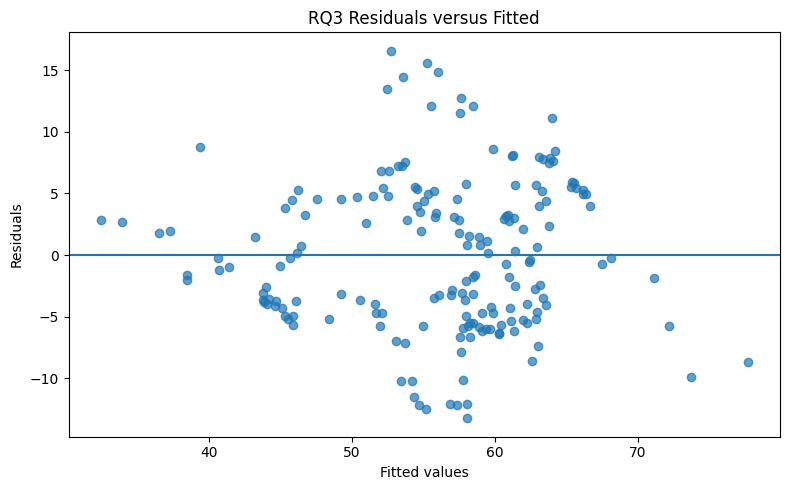

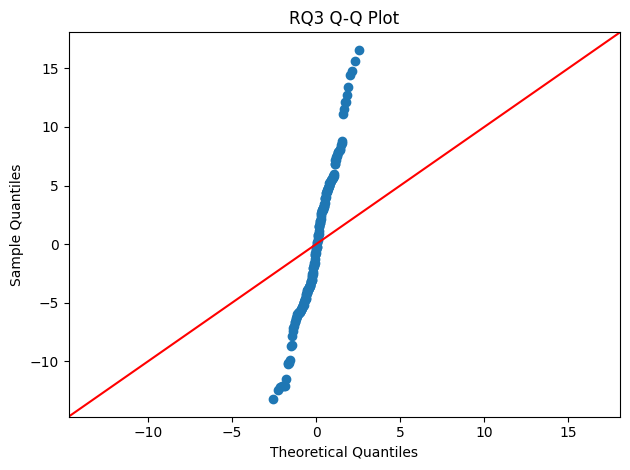

In [21]:
rq3_resid=rq3_ols.resid
bp=het_breuschpagan(rq3_resid,rq3_ols.model.exog)
rq3_diag=pd.DataFrame({"Diagnostic":["BP LM","BP p-value","BP F","BP F p-value","Durbin-Watson"],"Value":[bp[0],bp[1],bp[2],bp[3],durbin_watson(rq3_resid)]})
display(rq3_diag)
rq3_diag.to_csv(TABLE_DIR / "table_15_rq3_diagnostics.csv",index=False)
plt.figure(figsize=(8,5));plt.scatter(rq3_ols.fittedvalues,rq3_resid,alpha=.7);plt.axhline(0);plt.xlabel("Fitted values");plt.ylabel("Residuals");plt.title("RQ3 Residuals versus Fitted");plt.tight_layout();plt.savefig(FIG_DIR / "figure_10_rq3_residuals.png",dpi=300,bbox_inches="tight");plt.show()
sm.qqplot(rq3_resid,line="45");plt.title("RQ3 Q-Q Plot");plt.tight_layout();plt.savefig(FIG_DIR / "figure_11_rq3_qq.png",dpi=300,bbox_inches="tight");plt.show()



The Breusch–Pagan test is highly significant and the Durbin–Watson statistic is about **0.27**, confirming heteroskedasticity and strong positive serial correlation in pooled residuals. These findings support robust, country-clustered fixed-effects inference.

# 9. RQ4 — UHC moderation

### 9.1 Estimate UHC moderation models

The moderation models add the centred expenditure × centred UHC interaction to the two-way fixed-effects framework. Centring means the lower-order expenditure coefficient is evaluated at average UHC rather than at an impossible UHC value of zero.


In [22]:
rq4_controls=["HealthExpGDP","Physicians","OldAgeDependency","OOPExpenditure"]
rq4_terms=["CenteredLogHealthExpPC","CenteredUHCIndex","Expenditure_UHC_Interaction"]+rq4_controls
rq4a=df[["Country","Year","LifeExpectancy"]+rq4_terms].dropna().copy()
rq4b=df[["Country","Year","NCDMortality"]+rq4_terms].dropna().copy()
rq4a_fe=smf.ols(fe_formula("LifeExpectancy",rq4_terms),data=rq4a).fit(cov_type="cluster",cov_kwds={"groups":rq4a["Country"],"use_correction":True})
rq4b_fe=smf.ols(fe_formula("NCDMortality",rq4_terms),data=rq4b).fit(cov_type="cluster",cov_kwds={"groups":rq4b["Country"],"use_correction":True})
rq4a_table=coefficient_table(rq4a_fe,rq4_terms)
rq4b_table=coefficient_table(rq4b_fe,rq4_terms)
print("Life expectancy moderation")
display(rq4a_table)
print("NCD mortality moderation")
display(rq4b_table)
rq4a_table.to_csv(TABLE_DIR / "table_16_rq4a.csv",index=False)
rq4b_table.to_csv(TABLE_DIR / "table_17_rq4b.csv",index=False)


Life expectancy moderation


,Variable,Coefficient,Std_Error,Statistic,P_Value,CI_Lower,CI_Upper
0,CenteredLogHealthExpPC,0.898061,0.679985,1.320706,0.186599,-0.434686,2.230808
1,CenteredUHCIndex,-0.138996,0.039997,-3.475129,0.000511,-0.217390,-0.060603
2,Expenditure_UHC_Interaction,-0.023217,0.029596,-0.784458,0.432771,-0.081224,0.034790
3,HealthExpGDP,0.193784,0.158563,1.222130,0.221658,-0.116993,0.504562
4,Physicians,-0.263722,0.248015,-1.063331,0.287632,-0.749822,0.222378
5,OldAgeDependency,-0.141990,0.138961,-1.021792,0.306879,-0.414349,0.130370
6,OOPExpenditure,0.031954,0.017101,1.868508,0.061691,-0.001564,0.065471


NCD mortality moderation


,Variable,Coefficient,Std_Error,Statistic,P_Value,CI_Lower,CI_Upper
0,CenteredLogHealthExpPC,1.128379,2.285495,0.493713,0.621509,-3.351108,5.607866
1,CenteredUHCIndex,0.586333,0.161317,3.634672,0.000278,0.270158,0.902508
2,Expenditure_UHC_Interaction,0.240617,0.092895,2.590210,0.009592,0.058546,0.422687
3,HealthExpGDP,-0.307180,1.048238,-0.293044,0.769488,-2.361690,1.747329
4,Physicians,-1.821430,0.966409,-1.884740,0.059465,-3.715557,0.072698
5,OldAgeDependency,-0.379205,0.755262,-0.502084,0.615608,-1.859491,1.101081
6,OOPExpenditure,-0.030175,0.079796,-0.378151,0.705319,-0.186573,0.126223


### Output interpretation

The life-expectancy model provides no evidence that UHC coverage moderates the expenditure–life-expectancy relationship. The NCD-mortality interaction is statistically significant and positive, suggesting that the expenditure–NCD association may vary across UHC levels.

However, this unexpected direction should not be treated as a causal finding. Statistical significance is also fragile because the models use only **12 country clusters**. The conditional marginal effects and their confidence intervals are therefore examined next before drawing any substantive conclusion.


### 9.2 Calculate conditional marginal effects

Interaction coefficients are difficult to interpret directly. This cell calculates the conditional expenditure effect at the 25th, 50th, and 75th percentiles of UHC and supplies uncertainty using the model covariance matrix.


,Outcome,UHC_Percentile,UHC_Value,Marginal_Effect,Std_Error,CI_Lower,CI_Upper
0,Life expectancy,0.25,68.0,1.023496,0.623300,-0.198172,2.245164
1,Life expectancy,0.50,74.0,0.884195,0.688248,-0.464770,2.233161
2,Life expectancy,0.75,79.0,0.768112,0.769965,-0.741019,2.277242
3,Premature NCD mortality,0.25,68.0,-0.171619,2.207784,-4.498875,4.155637
4,Premature NCD mortality,0.50,74.0,1.272080,2.300653,-3.237200,5.781361
5,Premature NCD mortality,0.75,79.0,2.475163,2.473163,-2.372237,7.322564


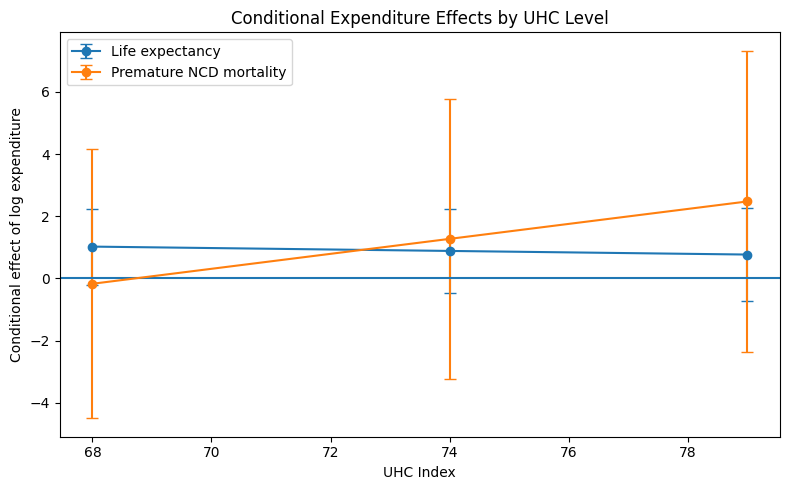

In [23]:
def marginal_effect_table(model,outcome_label):
    b1=model.params["CenteredLogHealthExpPC"]
    b3=model.params["Expenditure_UHC_Interaction"]
    cov=model.cov_params()
    rows=[]
    for q,uhc in df["UHCIndex"].quantile([.25,.5,.75]).items():
        c=uhc-df["UHCIndex"].mean()
        effect=b1+b3*c
        var=cov.loc["CenteredLogHealthExpPC","CenteredLogHealthExpPC"] + c*c*cov.loc["Expenditure_UHC_Interaction","Expenditure_UHC_Interaction"] + 2*c*cov.loc["CenteredLogHealthExpPC","Expenditure_UHC_Interaction"]
        se=np.sqrt(max(var,0))
        rows.append({"Outcome":outcome_label,"UHC_Percentile":q,"UHC_Value":uhc,"Marginal_Effect":effect,"Std_Error":se,"CI_Lower":effect-1.96*se,"CI_Upper":effect+1.96*se})
    return pd.DataFrame(rows)

rq4_marginal=pd.concat([marginal_effect_table(rq4a_fe,"Life expectancy"),marginal_effect_table(rq4b_fe,"Premature NCD mortality")],ignore_index=True)
display(rq4_marginal)
rq4_marginal.to_csv(TABLE_DIR / "table_18_rq4_marginal_effects.csv",index=False)
plt.figure(figsize=(8,5))
for label,g in rq4_marginal.groupby("Outcome"):
    plt.errorbar(g["UHC_Value"],g["Marginal_Effect"],yerr=1.96*g["Std_Error"],marker="o",capsize=4,label=label)
plt.axhline(0);plt.xlabel("UHC Index");plt.ylabel("Conditional effect of log expenditure");plt.title("Conditional Expenditure Effects by UHC Level");plt.legend();plt.tight_layout();plt.savefig(FIG_DIR / "figure_12_marginal_effects.png",dpi=300,bbox_inches="tight");plt.show()



The life-expectancy moderation model does not provide evidence of a conditional expenditure effect across UHC levels. Although the NCD-mortality interaction coefficient is statistically significant, the conditional expenditure effects at the 25th, 50th, and 75th UHC percentiles remain imprecise and their confidence intervals include zero.

RQ4 should therefore be reported as **preliminary and inconclusive**, rather than as evidence that UHC definitively changes the effect of health expenditure. The marginal-effect table and confidence-interval figure should be the primary RQ4 presentation in the report.


# 10. Machine-learning benchmarks

### 10.1 Tune and validate machine-learning models



Machine-learning hyperparameters must be selected without allowing the held-out country to influence tuning. This cell therefore uses **nested grouped validation**:

- the outer loop is leave-one-country-out validation;
- the inner loop is grouped cross-validation using only the training countries;
- Random Forest and Gradient Boosting are tuned against root mean squared error;
- a mean-only dummy model remains the transparent baseline;
- pooled out-of-fold predictions are retained for unbiased model comparison.

The grids are intentionally compact because the dataset contains only 12 countries and fewer than 300 observations. This balances methodological rigour with computational stability.


In [24]:
ml_features = full_features.copy()

# Compact, theory-informed tuning grids.
rf_param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 6],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt"]
}

gb_param_grid = {
    "model__n_estimators": [150, 300],
    "model__learning_rate": [0.03, 0.08],
    "model__max_depth": [1, 2],
    "model__min_samples_leaf": [2]
}

def nested_grouped_benchmark(data, target, features, label):
    """
    Tune each model using grouped inner cross-validation and evaluate it
    using leave-one-country-out outer validation.
    """
    model_df = data[["Country", target] + features].dropna().copy()
    X = model_df[features].reset_index(drop=True)
    y = model_df[target].to_numpy()
    groups = model_df["Country"].to_numpy()

    outer_cv = LeaveOneGroupOut()

    model_specs = {
        "Dummy mean": {
            "estimator": DummyRegressor(strategy="mean"),
            "param_grid": None
        },
        "Tuned Random Forest": {
            "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
            "param_grid": rf_param_grid
        },
        "Tuned Gradient Boosting": {
            "estimator": GradientBoostingRegressor(
                random_state=42,
                loss="squared_error"
            ),
            "param_grid": gb_param_grid
        }
    }

    result_rows = []
    prediction_tables = []
    tuning_rows = []
    fitted_models = {}

    for model_name, spec in model_specs.items():
        outer_predictions = np.full(len(model_df), np.nan)

        for fold_number, (train_idx, test_idx) in enumerate(
            outer_cv.split(X, y, groups),
            start=1
        ):
            held_out_country = groups[test_idx][0]

            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", clone(spec["estimator"]))
            ])

            if spec["param_grid"] is None:
                best_model = pipeline.fit(X.iloc[train_idx], y[train_idx])
                best_params = {}
                inner_rmse = np.nan
            else:
                train_groups = groups[train_idx]
                n_inner_splits = min(4, len(np.unique(train_groups)))
                inner_cv = GroupKFold(n_splits=n_inner_splits)

                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=spec["param_grid"],
                    scoring="neg_root_mean_squared_error",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True
                )
                search.fit(
                    X.iloc[train_idx],
                    y[train_idx],
                    groups=train_groups
                )

                best_model = search.best_estimator_
                best_params = {
                    key.replace("model__", ""): value
                    for key, value in search.best_params_.items()
                }
                inner_rmse = -float(search.best_score_)

            outer_predictions[test_idx] = best_model.predict(X.iloc[test_idx])

            tuning_rows.append({
                "Research_Question": label,
                "Model": model_name,
                "Outer_Fold": fold_number,
                "Held_Out_Country": held_out_country,
                "Inner_CV_RMSE": inner_rmse,
                "Best_Parameters": json.dumps(best_params, sort_keys=True)
            })

        model_metrics = metrics(y, outer_predictions)
        result_rows.append({
            "Research_Question": label,
            "Model": model_name,
            "Validation": "Nested leave-one-country-out",
            "N": len(y),
            "Held_Out_Countries": len(np.unique(groups)),
            **model_metrics
        })

        prediction_tables.append(pd.DataFrame({
            "Research_Question": label,
            "Model": model_name,
            "Country": groups,
            "Observed": y,
            "Predicted": outer_predictions,
            "Residual": y - outer_predictions
        }))

        # Fit one final tuned model to the full analytical sample for
        # exploratory importance and future prediction.
        final_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", clone(spec["estimator"]))
        ])

        if spec["param_grid"] is None:
            final_model = final_pipeline.fit(X, y)
            final_params = {}
        else:
            full_inner_cv = GroupKFold(
                n_splits=min(4, len(np.unique(groups)))
            )
            final_search = GridSearchCV(
                estimator=final_pipeline,
                param_grid=spec["param_grid"],
                scoring="neg_root_mean_squared_error",
                cv=full_inner_cv,
                n_jobs=-1,
                refit=True
            )
            final_search.fit(X, y, groups=groups)
            final_model = final_search.best_estimator_
            final_params = {
                key.replace("model__", ""): value
                for key, value in final_search.best_params_.items()
            }

        fitted_models[model_name] = final_model

        tuning_rows.append({
            "Research_Question": label,
            "Model": model_name,
            "Outer_Fold": "Full sample",
            "Held_Out_Country": "None",
            "Inner_CV_RMSE": np.nan,
            "Best_Parameters": json.dumps(final_params, sort_keys=True)
        })

    return (
        pd.DataFrame(result_rows),
        fitted_models,
        model_df,
        pd.concat(prediction_tables, ignore_index=True),
        pd.DataFrame(tuning_rows)
    )

rq1_ml, rq1_models, rq1_ml_df, rq1_oof, rq1_tuning = (
    nested_grouped_benchmark(
        df, "LifeExpectancy", ml_features, "RQ1"
    )
)

rq3_ml, rq3_models, rq3_ml_df, rq3_oof, rq3_tuning = (
    nested_grouped_benchmark(
        df, "NCDMortality", ml_features, "RQ3"
    )
)

ml_results = pd.concat([rq1_ml, rq3_ml], ignore_index=True)
oof_predictions = pd.concat([rq1_oof, rq3_oof], ignore_index=True)
tuning_results = pd.concat([rq1_tuning, rq3_tuning], ignore_index=True)

display(ml_results)
display(
    tuning_results[
        tuning_results["Outer_Fold"].eq("Full sample")
    ][["Research_Question", "Model", "Best_Parameters"]]
)

ml_results.to_csv(
    TABLE_DIR / "table_19_tuned_ml_nested_logo_performance.csv",
    index=False
)
oof_predictions.to_csv(
    TABLE_DIR / "table_20_tuned_ml_oof_predictions.csv",
    index=False
)
tuning_results.to_csv(
    TABLE_DIR / "table_21_hyperparameter_tuning_results.csv",
    index=False
)


,Research_Question,Model,Validation,N,Held_Out_Countries,RMSE,MAE,R2
0,RQ1,Dummy mean,Nested leave-one-country-out,189,12,4.157740,3.357895,-0.146741
1,RQ1,Tuned Random Forest,Nested leave-one-country-out,189,12,2.539241,2.055926,0.572281
2,RQ1,Tuned Gradient Boosting,Nested leave-one-country-out,189,12,2.454712,2.042323,0.600284
3,RQ3,Dummy mean,Nested leave-one-country-out,181,12,10.821791,8.917931,-0.181258
4,RQ3,Tuned Random Forest,Nested leave-one-country-out,181,12,8.776691,7.496878,0.223023
5,RQ3,Tuned Gradient Boosting,Nested leave-one-country-out,181,12,8.849684,7.335672,0.210046


,Research_Question,Model,Best_Parameters
12,RQ1,Dummy mean,{}
25,RQ1,Tuned Random Forest,"{""max_depth"": 6, ""max_features"": ""sqrt"", ""min_..."
38,RQ1,Tuned Gradient Boosting,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s..."
51,RQ3,Dummy mean,{}
64,RQ3,Tuned Random Forest,"{""max_depth"": 6, ""max_features"": ""sqrt"", ""min_..."
77,RQ3,Tuned Gradient Boosting,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s..."



The nested leave-one-country-out results estimate how well each tuned model generalises to a country that was excluded from both model fitting and hyperparameter selection. This is the most defensible predictive comparison in the notebook.

A tuned model should be preferred over the dummy baseline only when it achieves lower RMSE and MAE and a higher out-of-fold R². Negative R² indicates that the model predicts unseen countries worse than the training-country mean. The full-sample parameter table records the configuration selected for the final fitted version of each model.


### 10.2 Examine tuned-model permutation importance


Permutation importance is calculated from the final tuned Random Forest and Gradient Boosting models fitted to the complete analytical sample. It measures the change in predictive error when each feature is disrupted. Because this calculation uses the fitted full sample, it remains exploratory and should not be interpreted causally.


In [25]:
importance_rows = []

for rq_label, target, models, model_df in [
    ("RQ1", "LifeExpectancy", rq1_models, rq1_ml_df),
    ("RQ3", "NCDMortality", rq3_models, rq3_ml_df)
]:
    X = model_df[ml_features]
    y = model_df[target]

    for model_name, pipeline in models.items():
        if model_name == "Dummy mean":
            continue

        importance = permutation_importance(
            pipeline,
            X,
            y,
            n_repeats=30,
            random_state=42,
            scoring="neg_root_mean_squared_error"
        )

        for feature, mean_value, sd_value in zip(
            ml_features,
            importance.importances_mean,
            importance.importances_std
        ):
            importance_rows.append({
                "Research_Question": rq_label,
                "Model": model_name,
                "Feature": feature,
                "Importance_Mean": mean_value,
                "Importance_SD": sd_value
            })

importance_table = pd.DataFrame(importance_rows)

display(
    importance_table.sort_values(
        ["Research_Question", "Model", "Importance_Mean"],
        ascending=[True, True, False]
    )
)

importance_table.to_csv(
    TABLE_DIR / "table_22_tuned_model_permutation_importance.csv",
    index=False
)


,Research_Question,Model,Feature,Importance_Mean,Importance_SD
6,RQ1,Tuned Gradient Boosting,LogHealthExpPC,3.963923,0.153386
8,RQ1,Tuned Gradient Boosting,Physicians,0.450539,0.028651
10,RQ1,Tuned Gradient Boosting,OldAgeDependency,0.361581,0.033403
11,RQ1,Tuned Gradient Boosting,OOPExpenditure,0.203180,0.018549
9,RQ1,Tuned Gradient Boosting,UHCIndex,0.083038,0.010272
7,RQ1,Tuned Gradient Boosting,HealthExpGDP,0.028710,0.006454
0,RQ1,Tuned Random Forest,LogHealthExpPC,2.393751,0.111017
4,RQ1,Tuned Random Forest,OldAgeDependency,0.920075,0.058815
2,RQ1,Tuned Random Forest,Physicians,0.645522,0.029536
5,RQ1,Tuned Random Forest,OOPExpenditure,0.563506,0.027646



The ranking identifies variables on which the fitted ML models rely most strongly. Because importance is computed on the full fitted sample, it can be optimistic and must be described as exploratory predictive importance—not evidence that changing a variable would cause the outcome to change.

In [30]:
print(tuning_results[tuning_results["Outer_Fold"] == "Full sample"][["Research_Question","Model","Best_Parameters"]].to_string())

   Research_Question                    Model                                                                       Best_Parameters
12               RQ1               Dummy mean                                                                                    {}
25               RQ1      Tuned Random Forest  {"max_depth": 6, "max_features": "sqrt", "min_samples_leaf": 1, "n_estimators": 200}
38               RQ1  Tuned Gradient Boosting   {"learning_rate": 0.03, "max_depth": 2, "min_samples_leaf": 2, "n_estimators": 150}
51               RQ3               Dummy mean                                                                                    {}
64               RQ3      Tuned Random Forest  {"max_depth": 6, "max_features": "sqrt", "min_samples_leaf": 1, "n_estimators": 200}
77               RQ3  Tuned Gradient Boosting   {"learning_rate": 0.03, "max_depth": 2, "min_samples_leaf": 2, "n_estimators": 300}


# 11. Sensitivity analyses

### 11.1 Test sensitivity to physician-density missingness


Physician density is missing for 34% of observations. Reduced fixed-effects models omit that predictor to recover a substantially larger sample and test whether the main coefficients are sensitive to sample restriction.


In [26]:
reduced=["LogHealthExpPC","HealthExpGDP","UHCIndex","OldAgeDependency","OOPExpenditure"]
sens_rows=[]
for outcome,full_model,full_data in [("LifeExpectancy",rq1_fe,rq1),("NCDMortality",rq3_fe,rq3)]:
    d=df[["Country","Year",outcome]+reduced].dropna().copy()
    m=smf.ols(fe_formula(outcome,reduced),data=d).fit(cov_type="cluster",cov_kwds={"groups":d["Country"],"use_correction":True})
    sens_rows.append({"Outcome":outcome,"Specification":"Full with Physicians","N":int(full_model.nobs),"Adjusted_R2":full_model.rsquared_adj})
    sens_rows.append({"Outcome":outcome,"Specification":"Reduced without Physicians","N":int(m.nobs),"Adjusted_R2":m.rsquared_adj})
    with open(MODEL_DIR / f"{outcome}_reduced_fe.txt","w") as f:f.write(m.summary().as_text())
sensitivity=pd.DataFrame(sens_rows)
display(sensitivity)
sensitivity.to_csv(TABLE_DIR / "table_23_missingness_sensitivity.csv",index=False)


,Outcome,Specification,N,Adjusted_R2
0,LifeExpectancy,Full with Physicians,189,0.968552
1,LifeExpectancy,Reduced without Physicians,285,0.966733
2,NCDMortality,Full with Physicians,181,0.895063
3,NCDMortality,Reduced without Physicians,261,0.917901



Removing physician density increases the life-expectancy sample from **189 to 285** and the NCD-mortality sample from **181 to 261**. Material coefficient or fit changes indicate that the full-model findings may partly reflect the restricted availability of physician-density observations.

### 11.2 Test GCC-only sensitivity


A GCC-only analysis checks whether regional heterogeneity between GCC and non-GCC MENA countries drives the full-sample results. It is a sensitivity analysis rather than a replacement for the planned 12-country model.


In [27]:
gcc_rows=[]
for outcome in ["LifeExpectancy","NCDMortality"]:
    d=df[df["Country"].isin(gcc)][["Country","Year",outcome]+full_features].dropna().copy()
    m=smf.ols(fe_formula(outcome,full_features),data=d).fit(cov_type="cluster",cov_kwds={"groups":d["Country"],"use_correction":True})
    gcc_rows.append({"Outcome":outcome,"N":int(m.nobs),"Countries":d["Country"].nunique(),"Adjusted_R2":m.rsquared_adj})
gcc_sensitivity=pd.DataFrame(gcc_rows)
display(gcc_sensitivity)
gcc_sensitivity.to_csv(TABLE_DIR / "table_24_gcc_sensitivity.csv",index=False)


,Outcome,N,Countries,Adjusted_R2
0,LifeExpectancy,114,6,0.950980
1,NCDMortality,108,6,0.840731




The GCC-only models use only **six country clusters**, so their standard errors and p-values are especially fragile. These results should not be used as standalone confirmatory evidence. Their main value is directional comparison: consistency with the full sample supports robustness, while divergence signals regional heterogeneity that should be discussed as a limitation.


# 12. Consolidated performance, model selection, and export

### 12.1 Compare model performance and select preferred models


This is to separates **inferential model preference** from **predictive model preference**:

- two-way fixed effects remain the preferred explanatory models for RQ1 and RQ3 because they align with the panel research design;
- predictive preference is selected only among models evaluated under the same nested leave-one-country-out procedure;
- the preferred predictive model minimises RMSE, with MAE and R² retained as supporting criteria;
- a model is not accepted as useful merely because it is the best machine-learning option—it must also outperform the dummy baseline.

This distinction prevents an invalid direct ranking of in-sample OLS, fixed-effects inference, and out-of-country prediction.


In [28]:
# In-sample pooled OLS metrics are retained for descriptive context only.
performance = [
    {
        "Research_Question": "RQ1",
        "Model": "Pooled OLS",
        "Validation": "In-sample baseline",
        "N": len(rq1),
        **metrics(
            rq1["LifeExpectancy"],
            rq1_ols.predict(rq1)
        )
    },
    {
        "Research_Question": "RQ3",
        "Model": "Pooled OLS",
        "Validation": "In-sample baseline",
        "N": len(rq3),
        **metrics(
            rq3["NCDMortality"],
            rq3_ols.predict(rq3)
        )
    }
]

for _, row in ml_results.iterrows():
    performance.append({
        "Research_Question": row["Research_Question"],
        "Model": row["Model"],
        "Validation": row["Validation"],
        "N": row["N"],
        "RMSE": row["RMSE"],
        "MAE": row["MAE"],
        "R2": row["R2"]
    })

performance_table = pd.DataFrame(performance)

# Select preferred predictive models only from identically validated models.
preferred_predictive_rows = []

for rq_label in ["RQ1", "RQ3"]:
    candidates = ml_results[
        ml_results["Research_Question"].eq(rq_label)
    ].copy()

    preferred = candidates.sort_values(
        ["RMSE", "MAE", "R2"],
        ascending=[True, True, False]
    ).iloc[0]

    dummy = candidates[
        candidates["Model"].eq("Dummy mean")
    ].iloc[0]

    useful_vs_baseline = (
        preferred["RMSE"] < dummy["RMSE"]
        and preferred["MAE"] < dummy["MAE"]
        and preferred["R2"] > dummy["R2"]
    )

    preferred_predictive_rows.append({
        "Research_Question": rq_label,
        "Preferred_Predictive_Model": preferred["Model"],
        "RMSE": preferred["RMSE"],
        "MAE": preferred["MAE"],
        "R2": preferred["R2"],
        "Outperforms_Dummy_Baseline": bool(useful_vs_baseline),
        "Selection_Rule": "Lowest nested-LOGO RMSE; MAE and R2 as secondary criteria"
    })

preferred_predictive = pd.DataFrame(preferred_predictive_rows)

# Record the preferred model for each analytical purpose.
preferred_model_summary = pd.DataFrame([
    {
        "Purpose": "RQ1 explanatory inference",
        "Preferred_Model": "Two-way fixed effects with country-clustered standard errors",
        "Reason": "Matches the longitudinal panel design and estimates within-country associations"
    },
    {
        "Purpose": "RQ2 trajectory description",
        "Preferred_Model": "Country-specific linear trajectory model with HC3 standard errors",
        "Reason": "Directly estimates Saudi Arabia's trend relative to comparator countries"
    },
    {
        "Purpose": "RQ3 explanatory inference",
        "Preferred_Model": "Two-way fixed effects with country-clustered standard errors",
        "Reason": "Controls stable country differences and common year shocks"
    },
    {
        "Purpose": "RQ4 moderation inference",
        "Preferred_Model": "Two-way fixed-effects interaction model with marginal effects",
        "Reason": "Tests moderation while controlling country and year effects"
    },
    {
        "Purpose": "RQ1 predictive benchmark",
        "Preferred_Model": preferred_predictive.loc[
            preferred_predictive["Research_Question"].eq("RQ1"),
            "Preferred_Predictive_Model"
        ].iloc[0],
        "Reason": "Lowest nested leave-one-country-out RMSE among equally validated predictive models"
    },
    {
        "Purpose": "RQ3 predictive benchmark",
        "Preferred_Model": preferred_predictive.loc[
            preferred_predictive["Research_Question"].eq("RQ3"),
            "Preferred_Predictive_Model"
        ].iloc[0],
        "Reason": "Lowest nested leave-one-country-out RMSE among equally validated predictive models"
    }
])

display(performance_table)
display(preferred_predictive)
display(preferred_model_summary)

performance_table.to_csv(
    TABLE_DIR / "table_25_performance_comparison.csv",
    index=False
)
preferred_predictive.to_csv(
    TABLE_DIR / "table_26_preferred_predictive_models.csv",
    index=False
)
preferred_model_summary.to_csv(
    TABLE_DIR / "table_27_preferred_models_by_purpose.csv",
    index=False
)


,Research_Question,Model,Validation,N,RMSE,MAE,R2
0,RQ1,Pooled OLS,In-sample baseline,189,1.576584,1.266855,0.835114
1,RQ3,Pooled OLS,In-sample baseline,181,6.159158,5.155337,0.617361
2,RQ1,Dummy mean,Nested leave-one-country-out,189,4.157740,3.357895,-0.146741
3,RQ1,Tuned Random Forest,Nested leave-one-country-out,189,2.539241,2.055926,0.572281
4,RQ1,Tuned Gradient Boosting,Nested leave-one-country-out,189,2.454712,2.042323,0.600284
5,RQ3,Dummy mean,Nested leave-one-country-out,181,10.821791,8.917931,-0.181258
6,RQ3,Tuned Random Forest,Nested leave-one-country-out,181,8.776691,7.496878,0.223023
7,RQ3,Tuned Gradient Boosting,Nested leave-one-country-out,181,8.849684,7.335672,0.210046


,Research_Question,Preferred_Predictive_Model,RMSE,MAE,R2,Outperforms_Dummy_Baseline,Selection_Rule
0,RQ1,Tuned Gradient Boosting,2.454712,2.042323,0.600284,True,Lowest nested-LOGO RMSE; MAE and R2 as seconda...
1,RQ3,Tuned Random Forest,8.776691,7.496878,0.223023,True,Lowest nested-LOGO RMSE; MAE and R2 as seconda...


,Purpose,Preferred_Model,Reason
0,RQ1 explanatory inference,Two-way fixed effects with country-clustered s...,Matches the longitudinal panel design and esti...
1,RQ2 trajectory description,Country-specific linear trajectory model with ...,Directly estimates Saudi Arabia's trend relati...
2,RQ3 explanatory inference,Two-way fixed effects with country-clustered s...,Controls stable country differences and common...
3,RQ4 moderation inference,Two-way fixed-effects interaction model with m...,Tests moderation while controlling country and...
4,RQ1 predictive benchmark,Tuned Gradient Boosting,Lowest nested leave-one-country-out RMSE among...
5,RQ3 predictive benchmark,Tuned Random Forest,Lowest nested leave-one-country-out RMSE among...



The notebook now reports two complementary conclusions:

1. **Preferred explanatory models:** the two-way fixed-effects models remain preferred for RQ1 and RQ3 because they correspond to the approved longitudinal panel design. The RQ4 fixed-effects interaction model is preferred for moderation, and the country-specific trajectory model is preferred for RQ2.

2. **Preferred predictive models:** the notebook automatically selects the tuned model with the lowest nested leave-one-country-out RMSE for each outcome. The `Outperforms_Dummy_Baseline` column determines whether that winner provides meaningful predictive value beyond a training-country mean.

The pooled OLS metrics are displayed only as in-sample context and must not be used to choose the preferred predictive model.


### 12.2 Export the reproducibility package

The final cell exports the derived dataset, a consolidated Excel workbook, model summaries, figures, and a ZIP archive. This creates the reproducibility package required for the Interim Report and GitHub repository.




This final cell exports the analytical dataset, consolidates the principal tables in one Excel workbook, records reproducibility metadata, counts the generated artefacts, and packages the complete output directory into a single ZIP archive. Keeping all export actions in one cell prevents duplicate archives and ensures that the final package contains the same results used in the report.


In [29]:
# Export the analytical dataset with all derived variables.
df.to_csv(
    OUTPUT_DIR / "master_panel_with_derived_variables.csv",
    index=False
)

# Consolidate the principal report tables in one Excel workbook.
with pd.ExcelWriter(
    OUTPUT_DIR / "QM640_Final_Analysis_Tables.xlsx",
    engine="openpyxl"
) as writer:
    structural_checks.to_excel(
        writer, sheet_name="Structural_Audit", index=False
    )
    cleaning_log.to_excel(
        writer, sheet_name="Cleaning_Log", index=False
    )
    missingness.to_excel(
        writer, sheet_name="Missingness", index=False
    )
    descriptive.to_excel(
        writer, sheet_name="Descriptive"
    )
    rq_samples.to_excel(
        writer, sheet_name="RQ_Samples", index=False
    )
    rq1_fe_table.to_excel(
        writer, sheet_name="RQ1_FE", index=False
    )
    trajectory_table.to_excel(
        writer, sheet_name="RQ2_Slopes", index=False
    )
    rq3_fe_table.to_excel(
        writer, sheet_name="RQ3_FE", index=False
    )
    rq4a_table.to_excel(
        writer, sheet_name="RQ4a", index=False
    )
    rq4b_table.to_excel(
        writer, sheet_name="RQ4b", index=False
    )
    rq4_marginal.to_excel(
        writer, sheet_name="RQ4_Marginal", index=False
    )
    ml_results.to_excel(
        writer, sheet_name="ML_Performance", index=False
    )
    tuning_results.to_excel(
        writer, sheet_name="ML_Tuning", index=False
    )
    preferred_predictive.to_excel(
        writer, sheet_name="Preferred_Predictive", index=False
    )
    preferred_model_summary.to_excel(
        writer, sheet_name="Preferred_Models", index=False
    )
    sensitivity.to_excel(
        writer, sheet_name="Sensitivity", index=False
    )
    performance_table.to_excel(
        writer, sheet_name="Performance", index=False
    )

# Save a concise machine-readable summary for reproducibility.
analysis_summary = {
    "dataset_rows": int(len(df)),
    "original_variables": 12,
    "countries": int(df["Country"].nunique()),
    "year_start": int(df["Year"].min()),
    "year_end": int(df["Year"].max()),
    "rq1_complete_cases": int(
        df[["LifeExpectancy"] + full_features].dropna().shape[0]
    ),
    "rq2_complete_cases": int(
        df[["Country", "Year", "LifeExpectancy"]].dropna().shape[0]
    ),
    "rq3_complete_cases": int(
        df[["NCDMortality"] + full_features].dropna().shape[0]
    ),
    "rq4a_complete_cases": int(
        df[["LifeExpectancy"] + full_features].dropna().shape[0]
    ),
    "rq4b_complete_cases": int(
        df[["NCDMortality"] + full_features].dropna().shape[0]
    ),
    "physicians_missing_percent": round(
        float(df["Physicians"].isna().mean() * 100), 2
    )
}

with open(
    OUTPUT_DIR / "analysis_summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(analysis_summary, file, indent=2)

# Package all tables, figures, models, and metadata into one ZIP archive.
archive_path = shutil.make_archive(
    "QM640_Final_Analysis_Outputs",
    "zip",
    OUTPUT_DIR
)

print("Notebook completed successfully.")
print("Output archive:", archive_path)
print("Tables generated:", len(list(TABLE_DIR.glob("*"))))
print("Figures generated:", len(list(FIG_DIR.glob("*"))))
print("Model files generated:", len(list(MODEL_DIR.glob("*"))))


Notebook completed successfully.
Output archive: /content/QM640_Final_Analysis_Outputs.zip
Tables generated: 27
Figures generated: 12
Model files generated: 8




A successful run ends with **“Notebook completed successfully.”** and creates `QM640_Final_Analysis_Outputs.zip`. The archive contains the report-ready tables, figures, derived analytical dataset, model summaries, consolidated Excel workbook, and reproducibility metadata.

The printed artefact counts provide a final completeness check. This notebook should be rerun from top to bottom before submission, saved with its outputs, and uploaded to the project GitHub repository together with the final ZIP archive or selected report-ready outputs.


## Final interpretation guardrails

1. Fixed-effects estimates are within-country associations after country and year controls; they are not automatically causal.
2. Fixed-effects adjusted R² includes the substantive predictors, country indicators, and year indicators; it is not attributable solely to the health-system predictors.
3. With only 12 country clusters, cluster-robust p-values must be interpreted conservatively; GCC-only models with six clusters are especially fragile.
4. The trajectory model is a descriptive linear summary, not a causal evaluation of Vision 2030.
5. Pooled OLS in-sample metrics and nested leave-one-country-out predictive metrics answer different questions and must not be directly ranked.
6. Hyperparameter selection occurs only within training countries, protecting the held-out country from tuning leakage.
7. A preferred predictive model is considered useful only when it outperforms the dummy baseline on RMSE, MAE, and R².
8. Feature importance is predictive and exploratory, not causal.
9. RQ4 moderation findings are preliminary; conditional marginal-effect confidence intervals should guide interpretation.
10. HALE and HealthGap remain descriptive validation outcomes.


*******************


## AI Use Declaration

Generative AI tools were used to assist with code refinement, debugging, documentation, and explanatory comments. All data preparation, statistical analyses, machine learning implementation, interpretation of results, and final validation were performed and verified by the author, who accepts full responsibility for this notebook.